<a href="https://colab.research.google.com/github/janani26121992/AI-Projects/blob/main/CIFAR_Image_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***CIFAR Image Prediction Model***

In [1]:
from keras.datasets import cifar10
(xtrain,ytrain),(xtest,ytest) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [2]:
xtrain.shape

(50000, 32, 32, 3)

In [3]:
ytrain.shape

(50000, 1)

In [4]:
ytrain[0]

array([6], dtype=uint8)

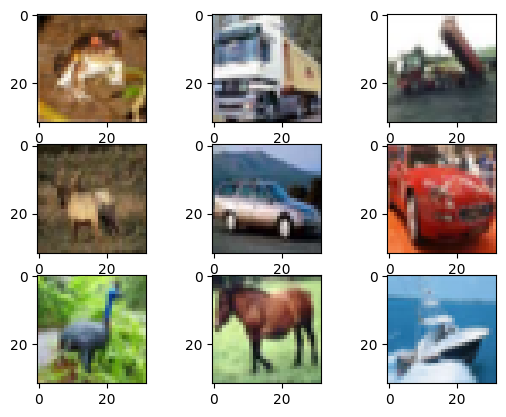

In [5]:
import matplotlib.pyplot as plt
fig,axs = plt.subplots(3,3)
k=0
for i in range(3):
  for j in range(3):
    axs[i][j].imshow(xtrain[k])
    k+=1

# ***Scaling of X and Y***

In [6]:
#X scaling
xtrain_scl = xtrain.astype("float32")/255
xtest_scl = xtest.astype("float32")/255

In [7]:
#y scaling
from keras.utils import to_categorical
ytrain_scl = to_categorical(ytrain)
ytest_scl = to_categorical(ytest)

In [8]:
ytrain_scl.shape

(50000, 10)

10 classes are there for this dataset

airplane

automobile

bird

cat

deer

dog

frog

horse

ship
truck

# ***Model Building***

In [9]:
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPool2D,Flatten,BatchNormalization,Dropout
from keras.callbacks import EarlyStopping

In [10]:
# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(32,32,3),))

# Add the Convolution layer, Maxpooling layer
model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Add another Convolution layer, Maxpooling layer
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Add the Flatten layer - convert ndarray into 1d array
model.add(Flatten())

# Add the Hidden layer
model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Add the output layer
model.add(Dense(ytrain_scl.shape[1],activation='softmax'))

In [14]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss',patience=15)

In [15]:
nn= model.fit(xtrain_scl,ytrain_scl,validation_split=0.2,epochs=100,callbacks=[es])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 52ms/step - accuracy: 0.8664 - loss: 0.3899 - val_accuracy: 0.6835 - val_loss: 0.9584
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.8748 - loss: 0.3583 - val_accuracy: 0.6561 - val_loss: 1.2691
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.8822 - loss: 0.3358 - val_accuracy: 0.6983 - val_loss: 1.0927
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.8920 - loss: 0.3063 - val_accuracy: 0.7015 - val_loss: 1.1619
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.8947 - loss: 0.2994 - val_accuracy: 0.6555 - val_loss: 1.3192
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 60ms/step - accuracy: 0.8996 - loss: 0.2881 - val_accuracy: 0.7128 - val_loss: 1.0664
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 56ms/step - accuracy: 0.9034 - loss: 0.2747 - val_accuracy: 0.6912 - val_loss: 1.1880
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 

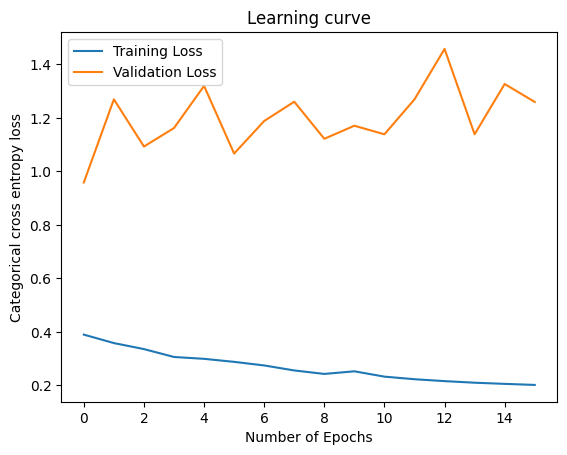

In [16]:
plt.plot(nn.history['loss'],label="Training Loss")
plt.plot(nn.history['val_loss'],label="Validation Loss")
plt.title("Learning curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Categorical cross entropy loss")
plt.legend()
plt.show()

Model evaluation

In [17]:
model.evaluate(xtrain_scl,ytrain_scl)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9276 - loss: 0.3064


[0.30638837814331055, 0.9276000261306763]

In [18]:
model.evaluate(xtest_scl,ytest_scl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7077 - loss: 1.3112


[1.3112108707427979, 0.7077000141143799]

In [19]:

from sklearn.metrics import ConfusionMatrixDisplay,classification_report
import numpy as np
yprobs = model.predict(xtest_scl)
ypreds = []
for i in yprobs:
  c=np.argmax(i)
  ypreds.append(c)
ypreds[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


[np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(0),
 np.int64(6),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(3),
 np.int64(1)]

In [20]:
print(classification_report(ytest,ypreds))

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1000
           1       0.80      0.88      0.84      1000
           2       0.61      0.61      0.61      1000
           3       0.48      0.59      0.53      1000
           4       0.74      0.57      0.64      1000
           5       0.56      0.63      0.59      1000
           6       0.85      0.74      0.79      1000
           7       0.75      0.76      0.76      1000
           8       0.88      0.78      0.83      1000
           9       0.84      0.73      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000

